In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()
token = os.getenv("HFTOKEN")
from huggingface_hub import login
login(token=token)

In [ ]:
import torch

def get_device():
    if torch.cuda.is_available():
        
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        
        return torch.device("mps")
    else:
        
        return torch.device("cpu")

device = get_device()
print(f"PyTorch is using: {device}")


x = torch.ones(1, device=device)
print(f"Tensor created on: {x.device}")

PyTorch is using: mps
Tensor created on: mps:0


In [1]:
import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "google-t5/t5-small"
    )
model = AutoModelForSeq2SeqLM.from_pretrained(
    "google-t5/t5-small",
    dtype=torch.float16,
    device_map="auto"
    )

input_ids = tokenizer("translate English to French: The weather is nice today.", return_tensors="pt").to(model.device)

output = model.generate(**input_ids, cache_implementation="static")
print(tokenizer.decode(output[0], skip_special_tokens=True))

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

/Users/mariiaonyshchuk/Documents/📚 Study/MMML/Labs/.venv/lib/python3.14/site-packages/transformers/generation/utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Le temps est agréable aujourd'hui.


In [6]:
%pip install torch transformers sentencepiece POT numpy seaborn matplotlib -q


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
import torch
device = torch.device("mps")



In [14]:
%pip install pot


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Layers : 6
Heads  : 8
d_model: 512

Encoder tokens (10): ['▁Transformer', 's', '▁are', '▁amazing', '▁for', '▁N', 'LP', '▁tasks', '.', '</s>']
Decoder tokens (6): ['▁N', 'LP', '▁is', '▁fun', '.', '</s>']

Number of decoder layers : 6
Cross-attention shape    : (1, 8, 6, 10)
  → (batch, heads=8, tgt_len=6, src_len=10)

Ground metric matrix M shape: (10, 10)  (positions normalised to [0,1])
M[0]  = [0.    0.111 0.222 0.333 0.444 0.556 0.667 0.778 0.889 1.   ]   ← cost from position 0 to all others
M[-1] = [1.    0.889 0.778 0.667 0.556 0.444 0.333 0.222 0.111 0.   ]  ← cost from last position to all others

Wasserstein distance: each layer vs uniform  (ε = 0.01)
Layer       W(π_l, uniform)  Interpretation
  1                0.278097  ← concentrated
  2                0.280482  ← concentrated
  3                0.295898  ← concentrated
  4                0.301152  ← concentrated
  5                0.250850  ← concentrated
  6                0.286277  ← concentrated

Sinkhorn regularised (ε

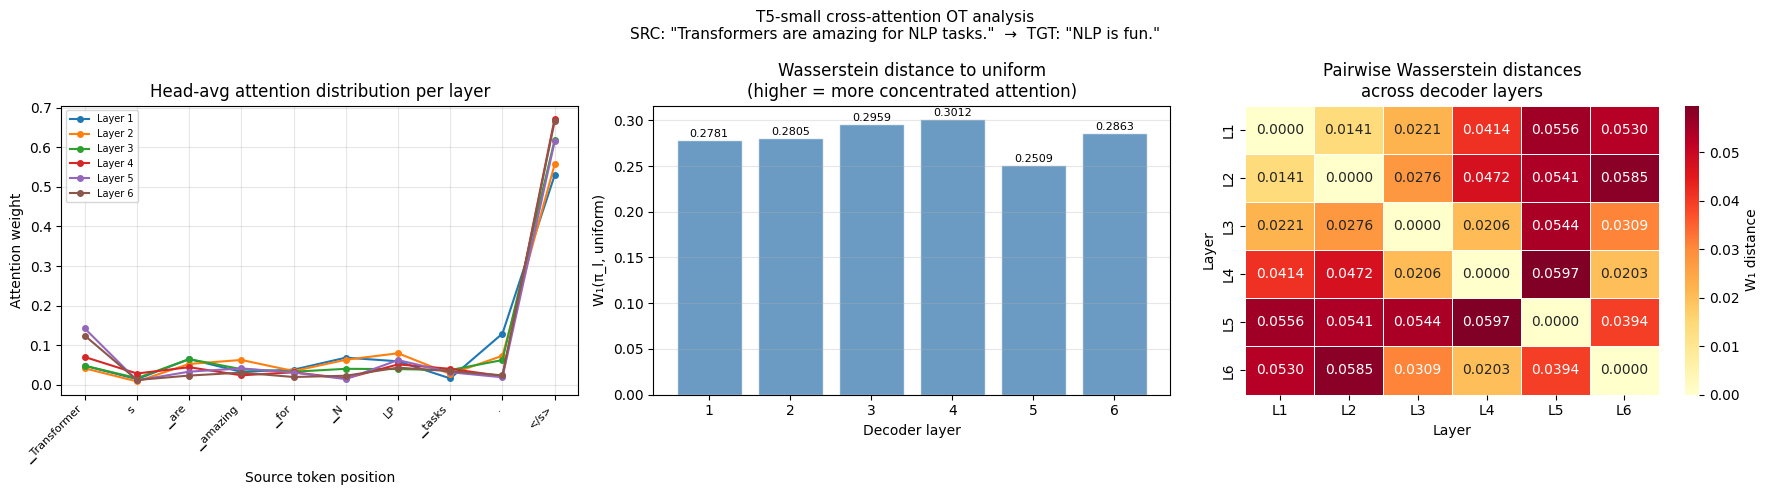


Plotting per-head heatmaps for Layer 1 (8 heads)...


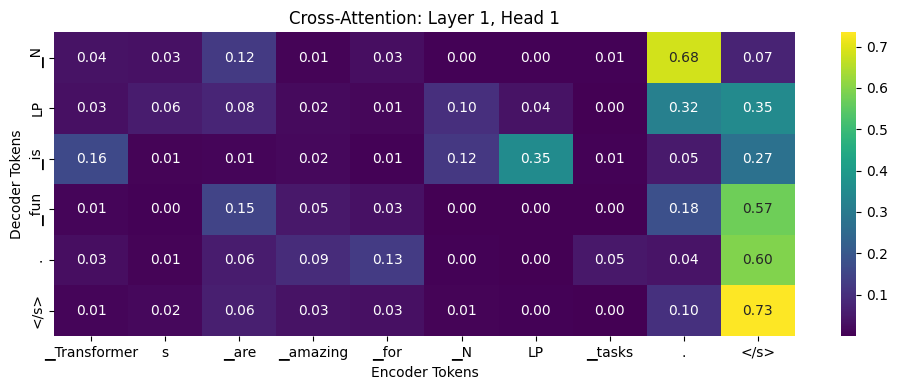

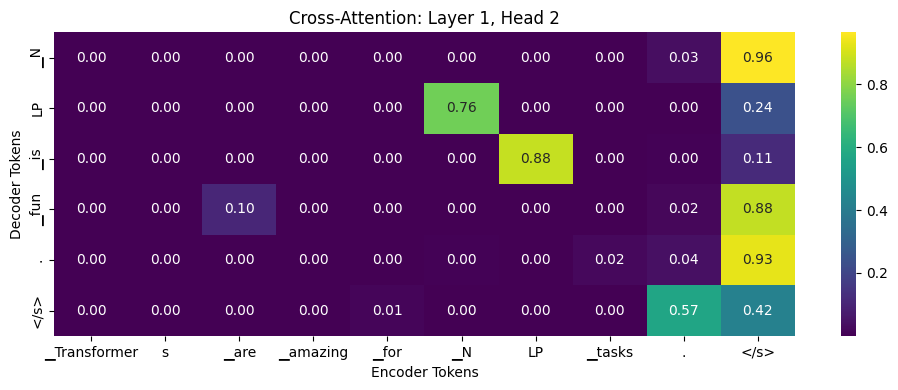

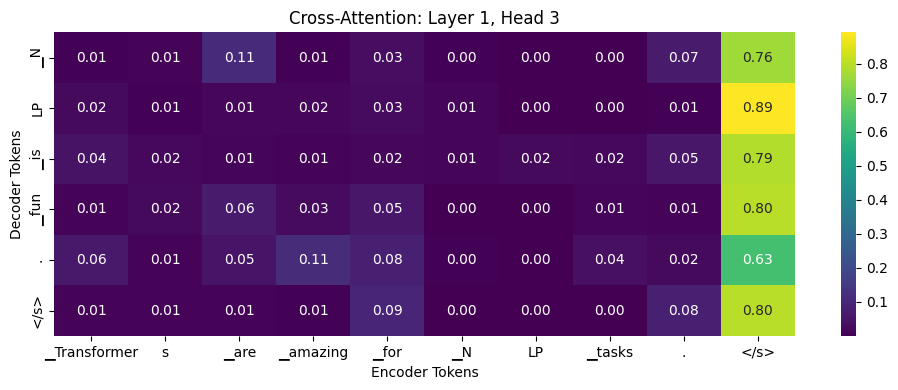

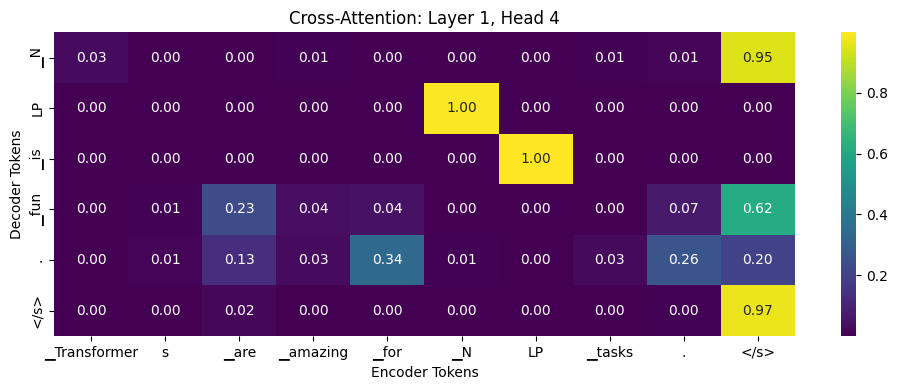

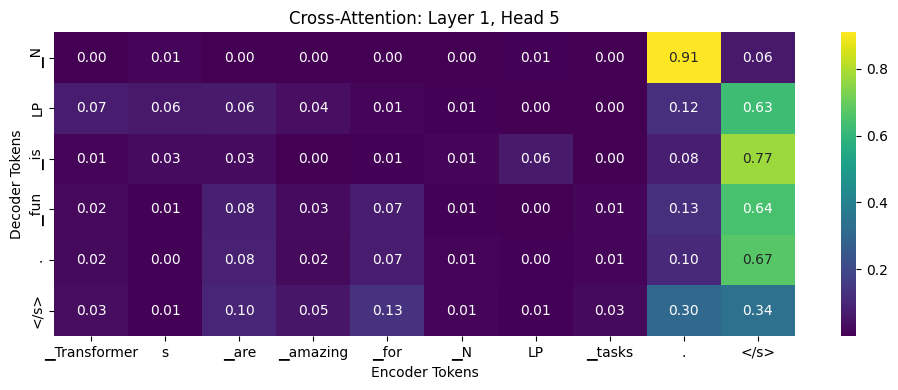

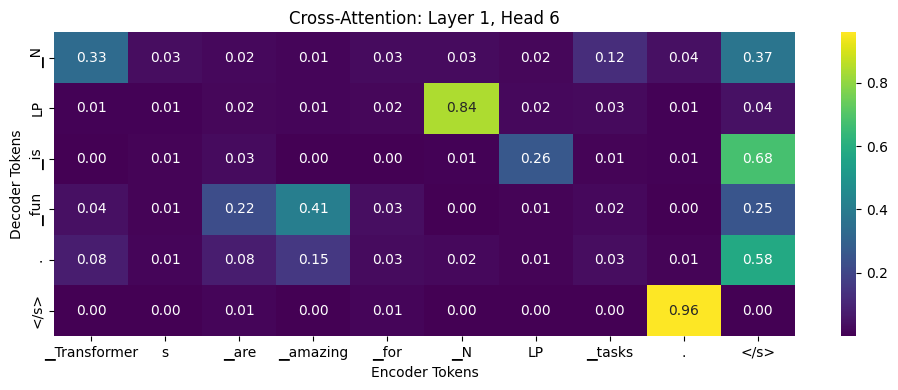

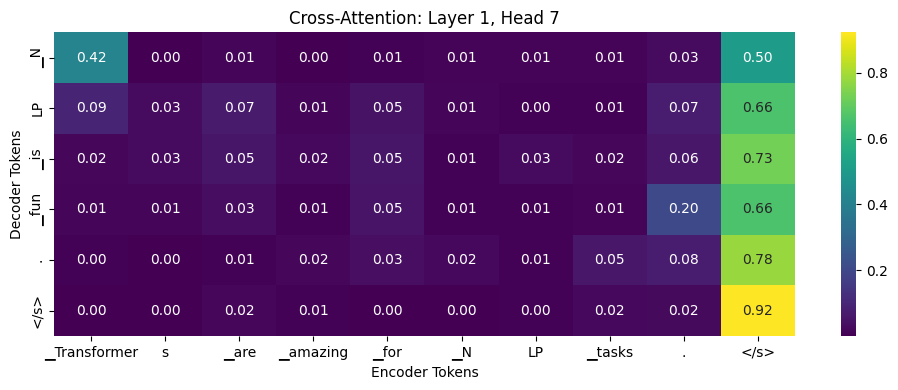

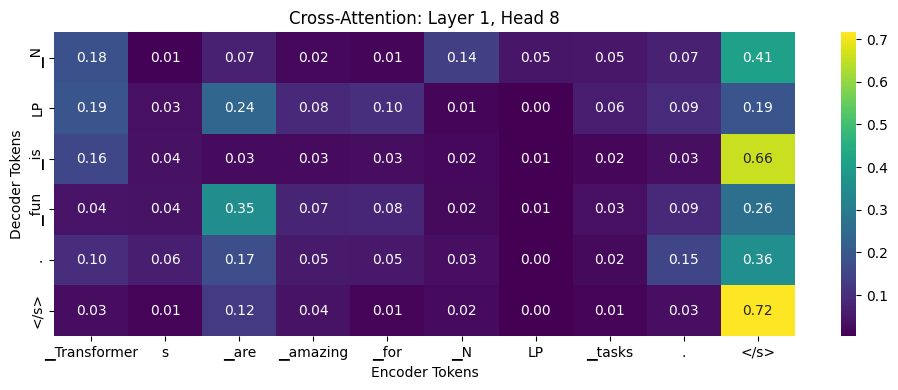


Done.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ot  

from transformers import T5Tokenizer, T5ForConditionalGeneration







if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")





model.to(device)
model.eval()

print(f"Layers : {model.config.num_layers}")
print(f"Heads  : {model.config.num_heads}")
print(f"d_model: {model.config.d_model}")
print()



input_text  = "Transformers are amazing for NLP tasks."
target_text = "NLP is fun."

input_ids = tokenizer(input_text, return_tensors="pt").input_ids.to(device)
labels = tokenizer(target_text, return_tensors="pt").input_ids.to(device)

encoder_tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
decoder_tokens = tokenizer.convert_ids_to_tokens(labels[0])

print(f"Encoder tokens ({len(encoder_tokens)}): {encoder_tokens}")
print(f"Decoder tokens ({len(decoder_tokens)}): {decoder_tokens}")
print()



with torch.no_grad():
    outputs = model(
        input_ids=input_ids,
        labels=labels,
        output_attentions=True,
    )

cross_attentions = outputs.cross_attentions


n_layers  = len(cross_attentions)
n_heads   = cross_attentions[0].shape[1]
tgt_len   = cross_attentions[0].shape[2]
src_len   = cross_attentions[0].shape[3]

print(f"Number of decoder layers : {n_layers}")
print(f"Cross-attention shape    : {tuple(cross_attentions[0].shape)}")
print(f"  → (batch, heads={n_heads}, tgt_len={tgt_len}, src_len={src_len})")
print()



layer_distributions = [] 

for layer_idx in range(n_layers):
    
    attn = cross_attentions[layer_idx][0]          
    
    
    avg_heads = attn.mean(dim=0).to(torch.float32).cpu().numpy() 
    avg_tgt   = avg_heads.mean(axis=0)             
    
    
    avg_tgt = avg_tgt / np.sum(avg_tgt)            
    
    layer_distributions.append(avg_tgt)






n = src_len
positions = np.arange(n, dtype=np.float64)

if n > 1:
    M = np.abs(positions[:, None] - positions[None, :]) / (n - 1)
else:
    M = np.zeros((1, 1))

print(f"Ground metric matrix M shape: {M.shape}  (positions normalised to [0,1])")
print(f"M[0]  = {np.round(M[0], 3)}   ← cost from position 0 to all others")
print(f"M[-1] = {np.round(M[-1], 3)}  ← cost from last position to all others")
print()








uniform = np.ones(n, dtype=np.float32) / n
uniform = uniform / np.sum(uniform)
eps = 0.01   

print("Wasserstein distance: each layer vs uniform  (ε = 0.01)")
print(f"{'Layer':<8} {'W(π_l, uniform)':>18}  Interpretation")
wass_to_unif = []
for i, dist in enumerate(layer_distributions):
    w = ot.emd2(dist, uniform, M)          
    wass_to_unif.append(w)
    interpretation = "concentrated" if w > 0.1 else "spread"
    print(f"  {i+1:<6} {w:>18.6f}  ← {interpretation}")

print()


print("Sinkhorn regularised (ε = 0.01) vs exact OT:")
print(f"{'Layer':<8} {'Exact OT':>12} {'Sinkhorn':>12} {'Difference':>12}")
for i, dist in enumerate(layer_distributions):
    exact   = wass_to_unif[i]
    sinkh   = ot.sinkhorn2(dist, uniform, M, reg=eps)
    print(f"  {i+1:<6} {exact:>12.6f} {sinkh:>12.6f} {abs(exact-sinkh):>12.6f}")
print()







print("Computing 6×6 pairwise Wasserstein distance matrix...")
W_matrix = np.zeros((n_layers, n_layers))

for i in range(n_layers):
    for j in range(n_layers):
        if i == j:
            W_matrix[i, j] = 0.0
        elif i < j:
            w = ot.emd2(layer_distributions[i], layer_distributions[j], M)
            W_matrix[i, j] = w
            W_matrix[j, i] = w   

print("Pairwise Wasserstein distance matrix W[i,j]:")
header = "       " + "".join(f"  L{j+1}   " for j in range(n_layers))
print(header)
for i in range(n_layers):
    row = f"  L{i+1}   " + "".join(f"{W_matrix[i,j]:7.4f} " for j in range(n_layers))
    print(row)
print()



fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f'T5-small cross-attention OT analysis\n'
    f'SRC: "{input_text}"  →  TGT: "{target_text}"',
    fontsize=11
)


ax = axes[0]
x = np.arange(src_len)
for i, dist in enumerate(layer_distributions):
    ax.plot(x, dist, marker="o", markersize=4, label=f"Layer {i+1}")
ax.set_xticks(x)
ax.set_xticklabels(encoder_tokens, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Source token position")
ax.set_ylabel("Attention weight")
ax.set_title("Head-avg attention distribution per layer")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)


ax = axes[1]
layers = np.arange(1, n_layers + 1)
bars = ax.bar(layers, wass_to_unif, color="steelblue", alpha=0.8, edgecolor="white")
ax.set_xlabel("Decoder layer")
ax.set_ylabel("W₁(π_l, uniform)")
ax.set_title("Wasserstein distance to uniform\n(higher = more concentrated attention)")
ax.set_xticks(layers)
for bar, val in zip(bars, wass_to_unif):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.4f}", ha="center", va="bottom", fontsize=8)
ax.grid(True, alpha=0.3, axis="y")


ax = axes[2]
layer_labels = [f"L{i+1}" for i in range(n_layers)]
sns.heatmap(
    W_matrix,
    ax=ax,
    annot=True,
    fmt=".4f",
    cmap="YlOrRd",
    xticklabels=layer_labels,
    yticklabels=layer_labels,
    cbar_kws={"label": "W₁ distance"},
    linewidths=0.5,
)
ax.set_title("Pairwise Wasserstein distances\nacross decoder layers")
ax.set_xlabel("Layer")
ax.set_ylabel("Layer")

plt.tight_layout()
plt.savefig("t5_ot_analysis.png", dpi=130, bbox_inches="tight")
print("Saved: t5_ot_analysis.png")
plt.show()



cross_attentions_first_layer = cross_attentions[0][0]  

print(f"\nPlotting per-head heatmaps for Layer 1 ({n_heads} heads)...")
for head in range(n_heads):
    plt.figure(figsize=(10, 4))
    sns.heatmap(
        cross_attentions_first_layer[head].detach().cpu().numpy(),
        xticklabels=encoder_tokens,
        yticklabels=decoder_tokens,
        cmap="viridis",
        annot=True,
        fmt=".2f",
    )
    plt.title(f"Cross-Attention: Layer 1, Head {head+1}")
    plt.xlabel("Encoder Tokens")
    plt.ylabel("Decoder Tokens")
    plt.tight_layout()
    plt.savefig(f"head_{head+1}_layer1.png", dpi=100)
    plt.show()

print("\nDone.") 

In [ ]:



!pip install -q datasets rouge-score

from datasets import load_dataset

dataset = load_dataset("abisee/cnn_dailymail", "3.0.0", split="test")

print(f"Dataset size: {len(dataset)} examples")
print(f"Columns: {dataset.column_names}")
print()

ex = dataset[0]
print("Article (first 300 chars):")
print(ex["article"][:300])
print()
print("Highlights:")
print(ex["highlights"])



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Generating test split: 100%|██████████| 11490/11490 [00:00<00:00, 176300.24 examples/s]


Dataset size: 11490 examples
Columns: ['article', 'highlights', 'id']

Article (first 300 chars):
(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the cou

Highlights:
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .


In [ ]:



import numpy as np
import torch
import ot


def build_cost_matrix(n: int) -> np.ndarray:
    """
    Normalised absolute-position ground metric.
    M[i,j] = |i-j| / (n-1)  in [0, 1]
    Ensures comparability across examples with different src lengths.
    """
    idx = np.arange(n, dtype=np.float64)
    M = np.abs(idx[:, None] - idx[None, :])
    if n > 1:
        M /= (n - 1)
    return M


def wasserstein1_sinkhorn(mu: np.ndarray,
                          nu: np.ndarray,
                          M: np.ndarray,
                          reg: float = 0.01) -> float:
    """
    Entropy-regularised W1 via Sinkhorn (POT library).
    reg=0.01 closely approximates exact W1 (see methodology report).
    """
    mu = mu.astype(np.float64) / mu.sum()
    nu = nu.astype(np.float64) / nu.sum()
    return float(ot.sinkhorn2(mu, nu, M, reg=reg, numIterations=500))


def extract_layer_distributions(model, tokenizer,
                                article_text: str,
                                max_src_len: int = 512,
                                max_gen_len: int = 64) -> tuple:
    """
    Run T5 generation on one article and return:
      - layer_dists : list[n_layers] of (src_len,) arrays
                      head-averaged, step-averaged cross-attention distributions
      - src_len     : number of encoder tokens
      - out_tokens  : generated token strings

    Following methodology report eq. (2):
      pi(l,t) = (1/H) * sum_h A(l,h,t)    [per step]
    Then averaged over decoding steps -> one dist per layer.
    """
    input_text = "summarize: " + article_text
    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        max_length=max_src_len,
        truncation=True
    ).to(model.device)

    src_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_gen_len,
            return_dict_in_generate=True,
            output_attentions=True,
        )

    
    
    cross_attentions = outputs.cross_attentions
    n_layers = len(cross_attentions[0])
    n_steps  = len(cross_attentions)

    layer_dists = []
    for layer_idx in range(n_layers):
        step_dists = []
        for t in range(n_steps):
            attn = cross_attentions[t][layer_idx]       
            dist = attn[0].mean(dim=0)[0].cpu().numpy() 
            dist = dist / dist.sum()
            step_dists.append(dist)
        layer_dists.append(np.mean(step_dists, axis=0)) 

    out_tokens = tokenizer.convert_ids_to_tokens(outputs.sequences[0])
    return layer_dists, src_len, out_tokens


def compute_layer_distance_matrix(layer_dists: list) -> np.ndarray:
    """
    Compute the n_layers x n_layers pairwise W1 distance matrix.
    """
    n_layers = len(layer_dists)
    n = len(layer_dists[0])
    M = build_cost_matrix(n)
    D = np.zeros((n_layers, n_layers))
    for i in range(n_layers):
        for j in range(i + 1, n_layers):
            d = wasserstein1_sinkhorn(layer_dists[i], layer_dists[j], M)
            D[i, j] = d
            D[j, i] = d
    return D


def wass_to_uniform(dist: np.ndarray, reg: float = 0.01) -> float:
    """
    W1 between distribution and uniform over same support.
    High -> concentrated (peaked). Low -> spread (flat).
    """
    n = len(dist)
    uniform = np.ones(n, dtype=np.float64) / n
    M = build_cost_matrix(n)
    return wasserstein1_sinkhorn(dist, uniform, M, reg=reg)


print("Utility functions loaded:")
print("  build_cost_matrix | wasserstein1_sinkhorn | wass_to_uniform")
print("  extract_layer_distributions | compute_layer_distance_matrix")


Utility functions loaded:
  build_cost_matrix | wasserstein1_sinkhorn | wass_to_uniform
  extract_layer_distributions | compute_layer_distance_matrix


Article length : 3612 chars
Highlights     : Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed ...

Encoder tokens (src_len) : 512
Decoder layers           : 6
Generated tokens         : ['<pad>', '▁the', '▁', 'ICC', '▁officially', '▁became', '▁the', '▁', '123', 'r', 'd', '▁member', '▁of', '▁the', '▁international', '▁criminal', '▁court', '▁', '.', '▁the', '▁', 'ICC', '▁has', '▁accepted', '▁its', '▁jurisdiction', '▁over', '▁', 'alleged', '▁crimes', '▁committed', '▁in', '▁the', '▁', 'occupied', '▁Palestinian', '▁territories', '▁', '.', '▁the', '▁', 'ICC', '▁opened', '▁', 'a', '▁preliminary', '▁examination', '▁into', '▁the', '▁situation', '▁in', '▁the', '▁', 'occupied', '▁territories', '▁', '.', '</s>']

Layer         W2U
--------------------
  L1        0.1233
  L2        0.2028
  L3        0.2308
  L4        0.2207
  L5        0.2330
  L6        0.2202


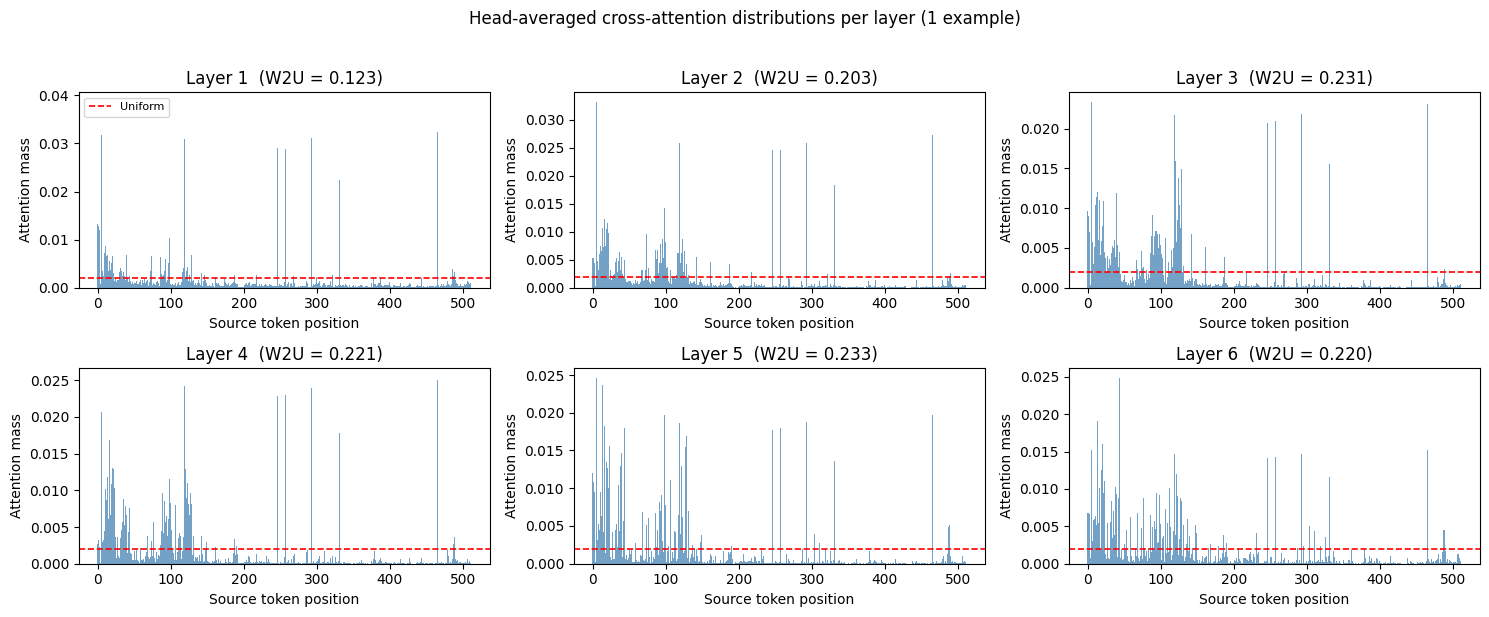

Saved: exp_a_sanity_dists.png


In [ ]:


import matplotlib.pyplot as plt
import seaborn as sns

sample  = dataset[0]
article = sample["article"]

print(f"Article length : {len(article)} chars")
print(f"Highlights     : {sample['highlights'][:150]}...\n")

layer_dists, src_len, out_tokens = extract_layer_distributions(
    model, tokenizer, article
)

n_layers = len(layer_dists)
print(f"Encoder tokens (src_len) : {src_len}")
print(f"Decoder layers           : {n_layers}")
print(f"Generated tokens         : {out_tokens}\n")


print(f"{'Layer':<8} {'W2U':>8}")
print("-" * 20)
for l, dist in enumerate(layer_dists):
    print(f"  L{l+1:<5}  {wass_to_uniform(dist):>8.4f}")


fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.flatten()
for l, dist in enumerate(layer_dists):
    w2u = wass_to_uniform(dist)
    axes[l].bar(range(src_len), dist, width=1.0,
                color="steelblue", alpha=0.75)
    axes[l].axhline(1/src_len, color="red", linestyle="--",
                    linewidth=1.2, label="Uniform")
    axes[l].set_title(f"Layer {l+1}  (W2U = {w2u:.3f})")
    axes[l].set_xlabel("Source token position")
    axes[l].set_ylabel("Attention mass")
    if l == 0:
        axes[l].legend(fontsize=8)

plt.suptitle("Head-averaged cross-attention distributions per layer (1 example)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("exp_a_sanity_dists.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: exp_a_sanity_dists.png")


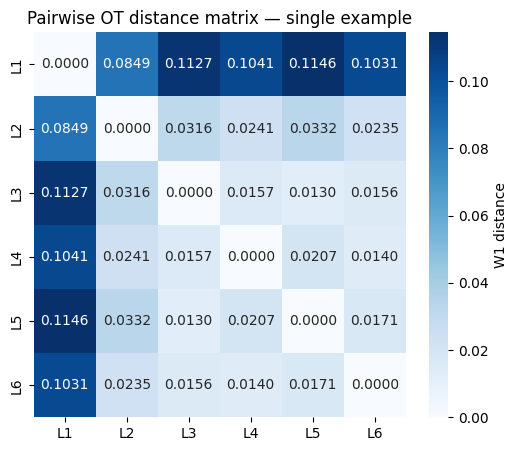

Most different pair : L1 <-> L5  (W1 = 0.1146)
Mean off-diagonal   : 0.0485
Saved: exp_a_sanity_matrix.png


In [ ]:


D_single = compute_layer_distance_matrix(layer_dists)
layer_labels = [f"L{i+1}" for i in range(n_layers)]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    D_single,
    xticklabels=layer_labels, yticklabels=layer_labels,
    annot=True, fmt=".4f", cmap="Blues", ax=ax,
    cbar_kws={"label": "W1 distance"}
)
ax.set_title("Pairwise OT distance matrix — single example", fontsize=12)
plt.show()

D_no_diag = D_single.copy()
np.fill_diagonal(D_no_diag, np.nan)
max_pair = np.unravel_index(np.nanargmax(D_no_diag), D_single.shape)
print(f"Most different pair : L{max_pair[0]+1} <-> L{max_pair[1]+1}  "
      f"(W1 = {D_single[max_pair]:.4f})")
print(f"Mean off-diagonal   : {np.nanmean(D_no_diag):.4f}")
print("Saved: exp_a_sanity_matrix.png")


In [ ]:




from tqdm.auto import tqdm

N_EXAMPLES  = 50
RANDOM_SEED = 42

rng     = np.random.default_rng(RANDOM_SEED)
indices = rng.choice(len(dataset), size=N_EXAMPLES, replace=False)

all_distance_matrices = []  
all_wass_to_unif      = []  
failed_indices        = []

print(f"Running Experiment A over {N_EXAMPLES} examples...")

for idx in tqdm(indices):
    try:
        article = dataset[int(idx)]["article"]
        layer_dists_i, _, _ = extract_layer_distributions(
            model, tokenizer, article
        )
        D = compute_layer_distance_matrix(layer_dists_i)
        all_distance_matrices.append(D)
        all_wass_to_unif.append(
            [wass_to_uniform(d) for d in layer_dists_i]
        )
    except Exception as e:
        print(f"  [!] Example {idx} failed: {e}")
        failed_indices.append(idx)

all_distance_matrices = np.array(all_distance_matrices)  
all_wass_to_unif      = np.array(all_wass_to_unif)       

print(f"\nCollected  : {len(all_distance_matrices)} examples")
print(f"Failed     : {len(failed_indices)}")
print(f"D matrices : {all_distance_matrices.shape}")
print(f"W2U array  : {all_wass_to_unif.shape}")






Running Experiment A over 50 examples...


100%|██████████| 50/50 [02:04<00:00,  2.50s/it]


Collected  : 50 examples
Failed     : 0
D matrices : (50, 6, 6)
W2U array  : (50, 6)
Saved: exp_a_distance_matrices.npy  exp_a_wass_to_unif.npy


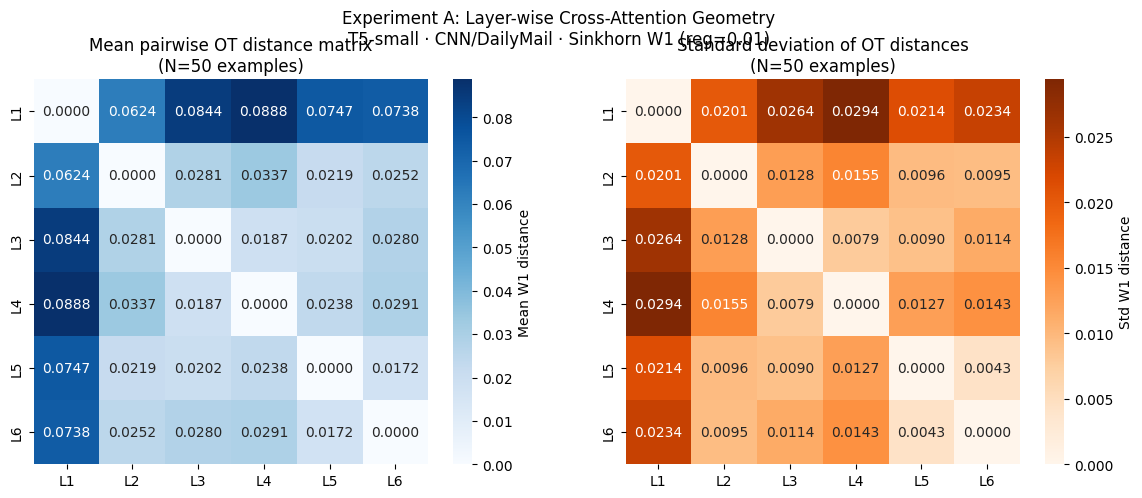

Most different pair : L1 <-> L4  (mean W1 = 0.0888)
Mean off-diagonal   : 0.0420


In [ ]:




D_mean   = np.mean(all_distance_matrices, axis=0)
D_median = np.median(all_distance_matrices, axis=0)
D_std    = np.std(all_distance_matrices, axis=0)

layer_labels = [f"L{i+1}" for i in range(6)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(D_mean, xticklabels=layer_labels, yticklabels=layer_labels,
            annot=True, fmt=".4f", cmap="Blues", ax=axes[0],
            cbar_kws={"label": "Mean W1 distance"})
axes[0].set_title(
    f"Mean pairwise OT distance matrix\n(N={len(all_distance_matrices)} examples)",
    fontsize=12)

sns.heatmap(D_std, xticklabels=layer_labels, yticklabels=layer_labels,
            annot=True, fmt=".4f", cmap="Oranges", ax=axes[1],
            cbar_kws={"label": "Std W1 distance"})
axes[1].set_title(
    f"Standard deviation of OT distances\n(N={len(all_distance_matrices)} examples)",
    fontsize=12)

plt.suptitle(
    "Experiment A: Layer-wise Cross-Attention Geometry\n"
    "T5-small · CNN/DailyMail · Sinkhorn W1 (reg=0.01)",
    fontsize=12, y=1.02)
plt.show()

D_no_diag = D_mean.copy()
np.fill_diagonal(D_no_diag, np.nan)
max_pair = np.unravel_index(np.nanargmax(D_no_diag), D_mean.shape)
print(f"Most different pair : L{max_pair[0]+1} <-> L{max_pair[1]+1}  "
      f"(mean W1 = {D_mean[max_pair]:.4f})")
print(f"Mean off-diagonal   : {np.nanmean(D_no_diag):.4f}")


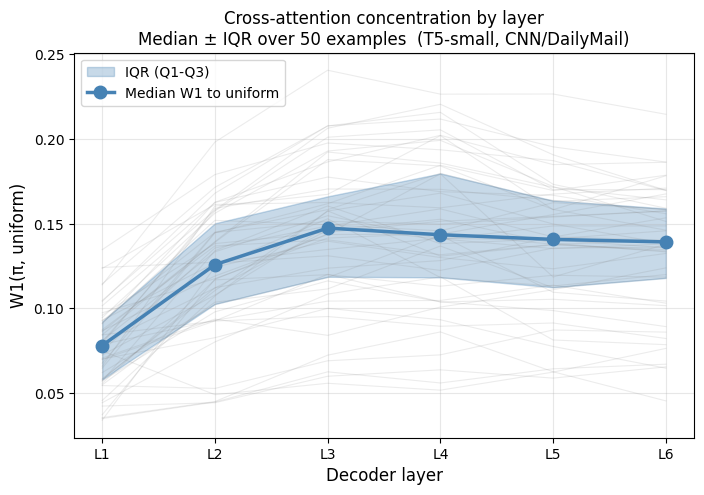

Layer        Median         Q1         Q3
------------------------------------------
  L1        0.0782     0.0582     0.0923
  L2        0.1259     0.1027     0.1502
  L3        0.1474     0.1187     0.1661
  L4        0.1435     0.1184     0.1796
  L5        0.1407     0.1125     0.1636
  L6        0.1392     0.1180     0.1590


In [ ]:


w2u_median = np.median(all_wass_to_unif,       axis=0)
w2u_q1     = np.percentile(all_wass_to_unif, 25, axis=0)
w2u_q3     = np.percentile(all_wass_to_unif, 75, axis=0)

layers = np.arange(1, 7)

fig, ax = plt.subplots(figsize=(8, 5))


for i in range(len(all_wass_to_unif)):
    ax.plot(layers, all_wass_to_unif[i], "-", color="gray",
            alpha=0.15, linewidth=0.8)

ax.fill_between(layers, w2u_q1, w2u_q3,
                alpha=0.3, color="steelblue", label="IQR (Q1-Q3)")
ax.plot(layers, w2u_median, "o-", color="steelblue",
        linewidth=2.5, markersize=9, label="Median W1 to uniform")

ax.set_xlabel("Decoder layer", fontsize=12)
ax.set_ylabel("W1(\u03c0, uniform)", fontsize=12)
ax.set_title(
    f"Cross-attention concentration by layer\n"
    f"Median \u00b1 IQR over {len(all_wass_to_unif)} examples  "
    f"(T5-small, CNN/DailyMail)",
    fontsize=12)
ax.set_xticks(layers)
ax.set_xticklabels([f"L{i}" for i in layers])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.show()

print(f"{'Layer':<8} {'Median':>10} {'Q1':>10} {'Q3':>10}")
print("-" * 42)
for l in range(6):
    print(f"  L{l+1}    {w2u_median[l]:>10.4f} "
          f"{w2u_q1[l]:>10.4f} {w2u_q3[l]:>10.4f}")


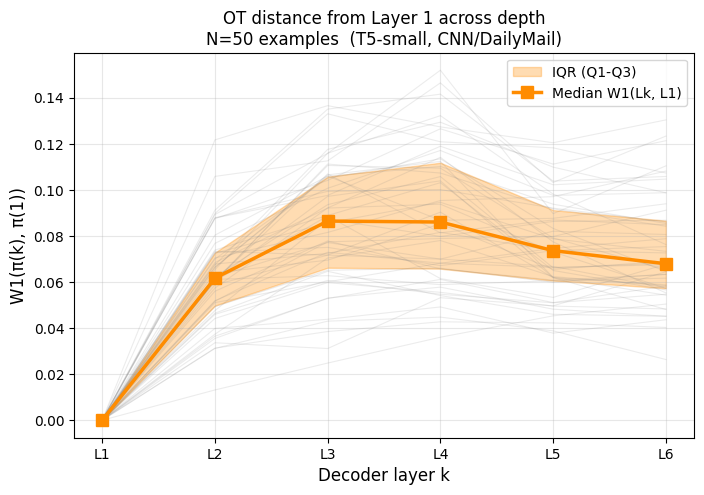

Layer        Median         Q1         Q3
------------------------------------------
  L1        0.0000     0.0000     0.0000
  L2        0.0616     0.0497     0.0727
  L3        0.0864     0.0661     0.1057
  L4        0.0860     0.0657     0.1117
  L5        0.0736     0.0606     0.0912
  L6        0.0679     0.0573     0.0866


In [ ]:





dist_from_L1 = all_distance_matrices[:, 0, :]   

d_median = np.median(dist_from_L1,       axis=0)
d_q1     = np.percentile(dist_from_L1, 25, axis=0)
d_q3     = np.percentile(dist_from_L1, 75, axis=0)

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(len(dist_from_L1)):
    ax.plot(layers, dist_from_L1[i], "-", color="gray",
            alpha=0.15, linewidth=0.8)

ax.fill_between(layers, d_q1, d_q3,
                alpha=0.3, color="darkorange", label="IQR (Q1-Q3)")
ax.plot(layers, d_median, "s-", color="darkorange",
        linewidth=2.5, markersize=9, label="Median W1(Lk, L1)")

ax.set_xlabel("Decoder layer k", fontsize=12)
ax.set_ylabel("W1(\u03c0(k), \u03c0(1))", fontsize=12)
ax.set_title(
    f"OT distance from Layer 1 across depth\n"
    f"N={len(dist_from_L1)} examples  (T5-small, CNN/DailyMail)",
    fontsize=12)
ax.set_xticks(layers)
ax.set_xticklabels([f"L{i}" for i in layers])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.show()

print(f"{'Layer':<8} {'Median':>10} {'Q1':>10} {'Q3':>10}")
print("-" * 42)
for l in range(6):
    print(f"  L{l+1}    {d_median[l]:>10.4f} "
          f"{d_q1[l]:>10.4f} {d_q3[l]:>10.4f}")



In [ ]:






!pip install -q datasets rouge-score scipy

import numpy as np
import torch
import ot
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datasets import load_dataset
from rouge_score import rouge_scorer
from scipy import stats
from tqdm.auto import tqdm


try:
    _ = model
    _ = tokenizer
    print("Model and tokenizer already in session.")
except NameError:
    from transformers import T5ForConditionalGeneration, T5Tokenizer
    MODEL_NAME = "google-t5/t5-small"
    print(f"Loading {MODEL_NAME}...")
    tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
    model     = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)
    device    = "cuda" if torch.cuda.is_available() else "cpu"
    model     = model.to(device).eval()
    print(f"Model loaded on {device}.")


try:
    _ = dataset
    print(f"Dataset already in session ({len(dataset)} examples).")
except NameError:
    dataset = load_dataset("abisee/cnn_dailymail", "3.0.0", split="test")
    print(f"Dataset loaded: {len(dataset)} examples.")

print("\nAll prerequisites satisfied. Ready for Experiment B.")


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Model and tokenizer already in session.
Dataset already in session (11490 examples).

All prerequisites satisfied. Ready for Experiment B.


In [ ]:









def build_cost_matrix(n: int) -> np.ndarray:
    """Normalised absolute-position ground metric. M[i,j] = |i-j|/(n-1)."""
    idx = np.arange(n, dtype=np.float64)
    M   = np.abs(idx[:, None] - idx[None, :])
    if n > 1:
        M /= (n - 1)
    return M


def wasserstein1_sinkhorn(mu, nu, M, reg=0.01):
    """Entropy-regularised W1 via Sinkhorn (POT)."""
    mu = mu.astype(np.float64) / mu.sum()
    nu = nu.astype(np.float64) / nu.sum()
    return float(ot.sinkhorn2(mu, nu, M, reg=reg, numIterations=500))


def wass_to_uniform(dist, reg=0.01):
    """c(l,t) — W1 between dist and uniform. High → concentrated."""
    n       = len(dist)
    uniform = np.ones(n, dtype=np.float64) / n
    M       = build_cost_matrix(n)
    return wasserstein1_sinkhorn(dist, uniform, M, reg=reg)




_scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def compute_rouge_l(hypothesis: str, reference: str) -> float:
    """ROUGE-L F1 between hypothesis and reference strings."""
    scores = _scorer.score(reference, hypothesis)
    return scores["rougeL"].fmeasure


def generate_and_extract(
    model,
    tokenizer,
    article_text: str,
    max_src_len: int = 512,
    max_gen_len: int = 64,
    reg: float = 0.01,
):
    """
    Run T5 on one article. Returns a dict with:
      summary_text   : decoded summary string
      layer_dists    : list[n_layers] of step-averaged (src_len,) arrays
                       — same as Exp A, used for layer-level c(l)
      step_dists     : list[n_layers] of list[n_steps] of (src_len,) arrays
                       — full (l, t) grid, used for c(l,t) trajectories
      src_len        : int
      n_steps        : int
    """
    input_text = "summarize: " + article_text
    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        max_length=max_src_len,
        truncation=True,
    ).to(model.device)

    src_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_gen_len,
            return_dict_in_generate=True,
            output_attentions=True,
        )

    summary_text = tokenizer.decode(
        outputs.sequences[0], skip_special_tokens=True
    )

    
    
    cross_attentions = outputs.cross_attentions
    n_layers = len(cross_attentions[0])
    n_steps  = len(cross_attentions)

    
    step_dists = []          
    for l in range(n_layers):
        layer_step = []
        for t in range(n_steps):
            attn = cross_attentions[t][l]           
            dist = attn[0].mean(dim=0)[0].cpu().numpy()  
            dist = dist / dist.sum()
            layer_step.append(dist)
        step_dists.append(layer_step)

    
    layer_dists = [
        np.mean(step_dists[l], axis=0) for l in range(n_layers)
    ]

    return dict(
        summary_text=summary_text,
        layer_dists=layer_dists,
        step_dists=step_dists,
        src_len=src_len,
        n_steps=n_steps,
    )


def compute_concentration_grid(step_dists, reg=0.01):
    """
    Compute c(l,t) = W1(π(l,t), uniform) for all (layer, step).
    Returns (n_layers, n_steps) array.
    """
    n_layers = len(step_dists)
    n_steps  = len(step_dists[0])
    grid = np.zeros((n_layers, n_steps))
    for l in range(n_layers):
        for t in range(n_steps):
            grid[l, t] = wass_to_uniform(step_dists[l][t], reg=reg)
    return grid


print("Exp B utilities loaded:")
print("  compute_rouge_l | generate_and_extract | compute_concentration_grid")

Exp B utilities loaded:
  compute_rouge_l | generate_and_extract | compute_concentration_grid


In [ ]:




sample    = dataset[0]
article   = sample["article"]
reference = sample["highlights"]

print("Reference summary:")
print(reference[:300])
print()

result = generate_and_extract(model, tokenizer, article)

rouge_l = compute_rouge_l(result["summary_text"], reference)

print(f"Generated summary : {result['summary_text']}")
print(f"ROUGE-L F1        : {rouge_l:.4f}")
print(f"src_len           : {result['src_len']}")
print(f"n_steps           : {result['n_steps']}")
print(f"n_layers          : {len(result['layer_dists'])}")
print()


grid = compute_concentration_grid(result["step_dists"])
print(f"c(l,t) grid shape : {grid.shape}  (n_layers x n_steps)")
print(f"c(l,t) mean       : {grid.mean():.4f}")
print(f"c(l,t) range      : [{grid.min():.4f}, {grid.max():.4f}]")
print()


print(f"{'Layer':<8} {'c(l) step-avg':>15} {'c(l) from grid':>16}")
print("-" * 42)
for l in range(len(result["layer_dists"])):
    c_direct = wass_to_uniform(result["layer_dists"][l])
    c_grid   = grid[l].mean()
    print(f"  L{l+1:<5}  {c_direct:>15.4f} {c_grid:>16.4f}")

print("\nSanity check passed.")

Reference summary:
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .

Generated summary : the ICC officially became the 123rd member of the international criminal court. the ICC has accepted its jurisdiction over alleged crimes committed in the occupied Palestinian territories. the ICC opened a preliminary examination into the situation in the occupied territories.
ROUGE-L F1        : 0.3514
src_len           : 512
n_steps           : 57
n_layers          : 6

c(l,t) grid shape : (6, 57)  (n_layers x n_steps)
c(l,t) mean       : 0.2073
c(l,t) range      : [0.0423, 0.3777]

Layer      c(l) step-avg   c(l) from grid
------------------------------------------
  L1               0.1233           0.1260
  L2               0.2028           0.2040
  L3               0.2308           0.2335
  L4               0.2

In [ ]:









N_EXAMPLES  = 5          
RANDOM_SEED = 42          
MAX_GEN_LEN = 64

rng     = np.random.default_rng(RANDOM_SEED)
indices = rng.choice(len(dataset), size=N_EXAMPLES, replace=False)

records         = []   
failed_indices  = []

print(f"Running Experiment B over {N_EXAMPLES} examples...")
print(f"Same random indices as Exp A (seed={RANDOM_SEED}) — results are aligned.\n")

for idx in tqdm(indices):
    try:
        sample    = dataset[int(idx)]
        article   = sample["article"]
        reference = sample["highlights"]

        result  = generate_and_extract(model, tokenizer, article,
                                       max_gen_len=MAX_GEN_LEN)
        rouge_l = compute_rouge_l(result["summary_text"], reference)

        
        layer_concentration = np.array(
            [wass_to_uniform(d) for d in result["layer_dists"]]
        )  

        
        concentration_grid = compute_concentration_grid(result["step_dists"])
        

        records.append(dict(
            dataset_idx          = int(idx),
            rouge_l              = rouge_l,
            summary_text         = result["summary_text"],
            reference_text       = reference,
            src_len              = result["src_len"],
            n_steps              = result["n_steps"],
            layer_concentration  = layer_concentration,
            concentration_grid   = concentration_grid,
        ))

    except Exception as e:
        print(f"  [!] Example {idx} failed: {e}")
        failed_indices.append(int(idx))


rouge_scores = np.array([r["rouge_l"] for r in records])
print(f"\nCollected  : {len(records)} examples")
print(f"Failed     : {len(failed_indices)}")
print(f"ROUGE-L    : mean={rouge_scores.mean():.4f}  "
      f"median={np.median(rouge_scores):.4f}  "
      f"std={rouge_scores.std():.4f}")
print(f"            range=[{rouge_scores.min():.4f}, {rouge_scores.max():.4f}]")


np.save("exp_b_rouge_scores.npy", rouge_scores)
np.save("exp_b_layer_concentration.npy",
        np.array([r["layer_concentration"] for r in records]))
print("\nSaved: exp_b_rouge_scores.npy  exp_b_layer_concentration.npy")

Running Experiment B over 5 examples...
Same random indices as Exp A (seed=42) — results are aligned.



100%|██████████| 5/5 [01:41<00:00, 20.29s/it]


Collected  : 5 examples
Failed     : 0
ROUGE-L    : mean=0.2804  median=0.2689  std=0.0795
            range=[0.2000, 0.4286]

Saved: exp_b_rouge_scores.npy  exp_b_layer_concentration.npy


In [ ]:







rouge_scores = np.array([r["rouge_l"] for r in records])
median_rl    = np.median(rouge_scores)

high_mask = rouge_scores >= median_rl
low_mask  = ~high_mask

high_records = [r for r, m in zip(records, high_mask) if m]
low_records  = [r for r, m in zip(records, low_mask)  if m]

print(f"Median ROUGE-L : {median_rl:.4f}")
print(f"HIGH group     : {len(high_records)} examples  "
      f"(ROUGE-L >= {median_rl:.4f})")
print(f"LOW  group     : {len(low_records)} examples  "
      f"(ROUGE-L <  {median_rl:.4f})")
print()
print(f"HIGH ROUGE-L   : mean={np.mean([r['rouge_l'] for r in high_records]):.4f}  "
      f"std={np.std([r['rouge_l'] for r in high_records]):.4f}")
print(f"LOW  ROUGE-L   : mean={np.mean([r['rouge_l'] for r in low_records]):.4f}  "
      f"std={np.std([r['rouge_l'] for r in low_records]):.4f}")


high_conc = np.array([r["layer_concentration"] for r in high_records])
low_conc  = np.array([r["layer_concentration"] for r in low_records])

print(f"\nhigh_conc shape : {high_conc.shape}")
print(f"low_conc  shape : {low_conc.shape}")

Median ROUGE-L : 0.2689
HIGH group     : 3 examples  (ROUGE-L >= 0.2689)
LOW  group     : 2 examples  (ROUGE-L <  0.2689)

HIGH ROUGE-L   : mean=0.3257  std=0.0729
LOW  ROUGE-L   : mean=0.2125  std=0.0125

high_conc shape : (3, 6)
low_conc  shape : (2, 6)


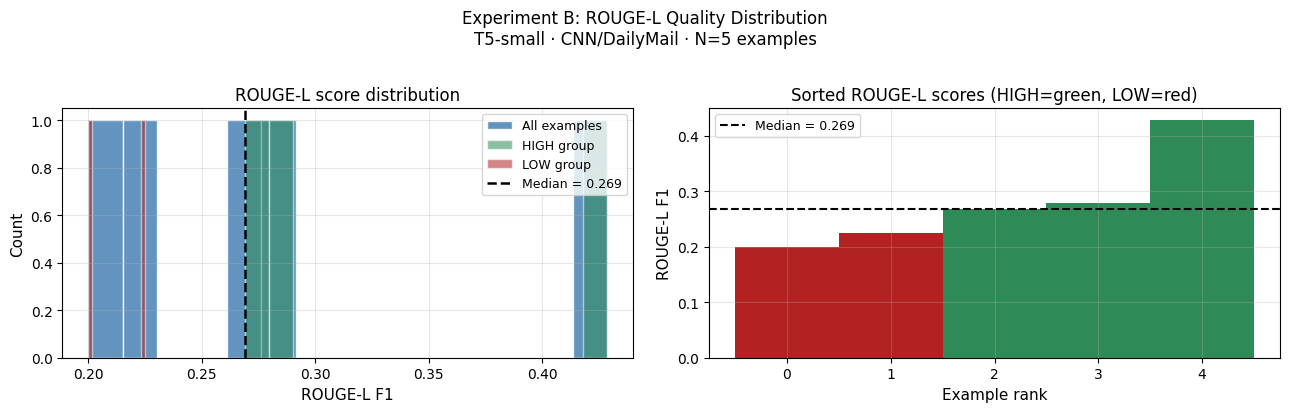

Saved: exp_b_rouge_distribution.png


In [ ]:




fig, axes = plt.subplots(1, 2, figsize=(13, 4))


ax = axes[0]
ax.hist(rouge_scores, bins=15, color="steelblue", edgecolor="white",
        alpha=0.85, label="All examples")
ax.hist([r["rouge_l"] for r in high_records], bins=15,
        color="seagreen", edgecolor="white", alpha=0.55, label="HIGH group")
ax.hist([r["rouge_l"] for r in low_records], bins=15,
        color="firebrick", edgecolor="white", alpha=0.55, label="LOW group")
ax.axvline(median_rl, color="black", linewidth=1.8, linestyle="--",
           label=f"Median = {median_rl:.3f}")
ax.set_xlabel("ROUGE-L F1", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("ROUGE-L score distribution", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)


ax = axes[1]
sorted_scores = np.sort(rouge_scores)
colors = ["seagreen" if s >= median_rl else "firebrick" for s in sorted_scores]
ax.bar(range(len(sorted_scores)), sorted_scores, color=colors, width=1.0)
ax.axhline(median_rl, color="black", linewidth=1.5, linestyle="--",
           label=f"Median = {median_rl:.3f}")
ax.set_xlabel("Example rank", fontsize=11)
ax.set_ylabel("ROUGE-L F1", fontsize=11)
ax.set_title("Sorted ROUGE-L scores (HIGH=green, LOW=red)", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle(
    f"Experiment B: ROUGE-L Quality Distribution\n"
    f"T5-small · CNN/DailyMail · N={len(records)} examples",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig("exp_b_rouge_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: exp_b_rouge_distribution.png")

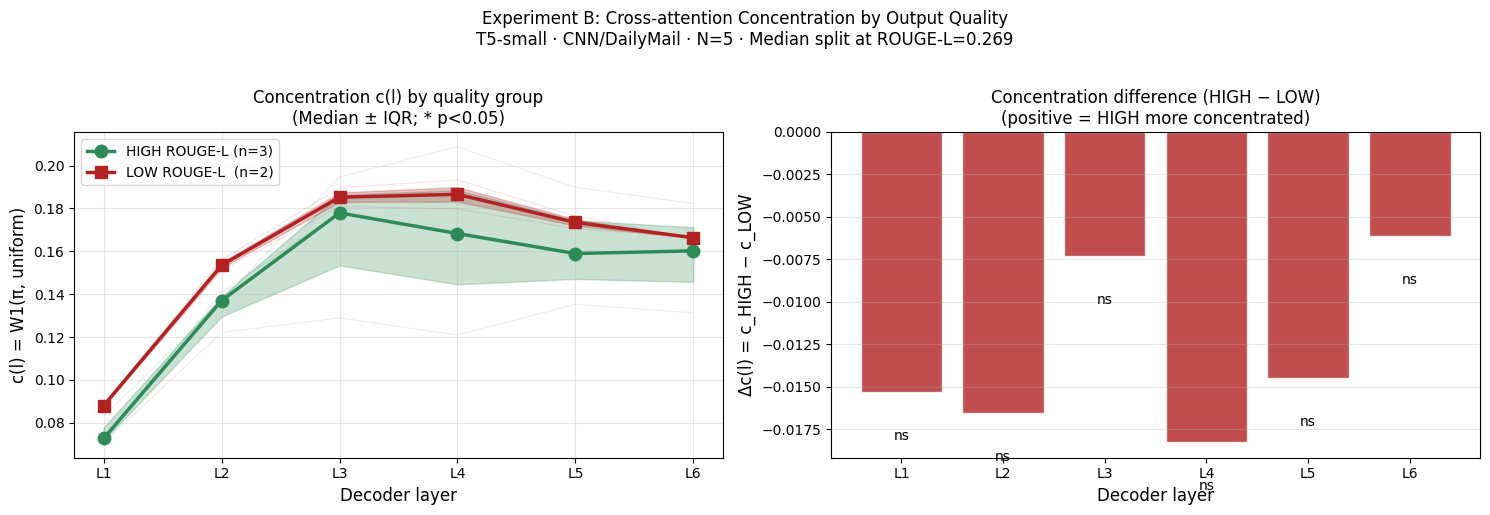


Layer      HIGH med    LOW med          Δ     U-stat    p-value    sig
----------------------------------------------------------------------
  L1          0.0727     0.0880    -0.0153        0.0     0.2000     ns
  L2          0.1370     0.1536    -0.0166        0.0     0.2000     ns
  L3          0.1779     0.1852    -0.0073        2.0     0.8000     ns
  L4          0.1683     0.1866    -0.0183        2.0     0.8000     ns
  L5          0.1590     0.1735    -0.0145        2.0     0.8000     ns
  L6          0.1602     0.1664    -0.0061        2.0     0.8000     ns

Saved: exp_b_concentration_high_vs_low.png


In [ ]:







from scipy.stats import mannwhitneyu

n_layers   = high_conc.shape[1]
layers     = np.arange(1, n_layers + 1)
layer_lbls = [f"L{i}" for i in layers]


high_med = np.median(high_conc, axis=0)
high_q1  = np.percentile(high_conc, 25, axis=0)
high_q3  = np.percentile(high_conc, 75, axis=0)

low_med  = np.median(low_conc, axis=0)
low_q1   = np.percentile(low_conc, 25, axis=0)
low_q3   = np.percentile(low_conc, 75, axis=0)


pvals  = []
ustats = []
for l in range(n_layers):
    u, p = mannwhitneyu(high_conc[:, l], low_conc[:, l], alternative="two-sided")
    pvals.append(p)
    ustats.append(u)


fig, axes = plt.subplots(1, 2, figsize=(15, 5))


ax = axes[0]


for i in range(len(high_conc)):
    ax.plot(layers, high_conc[i], "-", color="seagreen", alpha=0.12, lw=0.8)
for i in range(len(low_conc)):
    ax.plot(layers, low_conc[i], "-", color="firebrick", alpha=0.12, lw=0.8)

ax.fill_between(layers, high_q1, high_q3, alpha=0.25, color="seagreen")
ax.fill_between(layers, low_q1,  low_q3,  alpha=0.25, color="firebrick")
ax.plot(layers, high_med, "o-", color="seagreen",
        lw=2.5, ms=9, label=f"HIGH ROUGE-L (n={len(high_records)})")
ax.plot(layers, low_med,  "s-", color="firebrick",
        lw=2.5, ms=9, label=f"LOW ROUGE-L  (n={len(low_records)})")


y_top = max(high_q3.max(), low_q3.max())
for l, p in enumerate(pvals):
    if p < 0.05:
        sig = "***" if p < 0.001 else ("**" if p < 0.01 else "*")
        ax.text(layers[l], y_top * 1.04, sig, ha="center",
                fontsize=11, color="black")

ax.set_xlabel("Decoder layer", fontsize=12)
ax.set_ylabel("c(l) = W1(π, uniform)", fontsize=12)
ax.set_xticks(layers)
ax.set_xticklabels(layer_lbls)
ax.set_title("Concentration c(l) by quality group\n(Median ± IQR; * p<0.05)",
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)


ax = axes[1]
delta = high_med - low_med
bar_colors = ["seagreen" if d > 0 else "firebrick" for d in delta]
bars = ax.bar(layer_lbls, delta, color=bar_colors, alpha=0.8, edgecolor="white")
ax.axhline(0, color="black", linewidth=1.2)


for l, (bar, p) in enumerate(zip(bars, pvals)):
    sig = "ns"
    if p < 0.001:  sig = "***"
    elif p < 0.01: sig = "**"
    elif p < 0.05: sig = "*"
    y_pos = bar.get_height() + (0.001 if bar.get_height() >= 0 else -0.003)
    ax.text(bar.get_x() + bar.get_width() / 2, y_pos, sig,
            ha="center", va="bottom", fontsize=10)

ax.set_xlabel("Decoder layer", fontsize=12)
ax.set_ylabel("Δc(l) = c_HIGH − c_LOW", fontsize=12)
ax.set_title("Concentration difference (HIGH − LOW)\n(positive = HIGH more concentrated)",
             fontsize=12)
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(
    f"Experiment B: Cross-attention Concentration by Output Quality\n"
    f"T5-small · CNN/DailyMail · N={len(records)} · Median split at ROUGE-L={median_rl:.3f}",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig("exp_b_concentration_high_vs_low.png", dpi=150, bbox_inches="tight")
plt.show()


print(f"\n{'Layer':<8} {'HIGH med':>10} {'LOW med':>10} {'Δ':>10} "
      f"{'U-stat':>10} {'p-value':>10} {'sig':>6}")
print("-" * 70)
for l in range(n_layers):
    sig = "ns"
    if pvals[l] < 0.001:  sig = "***"
    elif pvals[l] < 0.01: sig = "**"
    elif pvals[l] < 0.05: sig = "*"
    print(f"  L{l+1:<5}  {high_med[l]:>10.4f} {low_med[l]:>10.4f} "
          f"{delta[l]:>+10.4f} {ustats[l]:>10.1f} {pvals[l]:>10.4f} {sig:>6}")

print("\nSaved: exp_b_concentration_high_vs_low.png")